# 30d. Multi-Tenant Isolation

**Tier:** Production & Safety
**Estimated time:** 55 minutes
**Prerequisites:** 13c (Inference Economics), 22b (Agent Memory Systems), 28b (Tool Contracts & Reliability), 30 (Security & Guardrails), 32 (Cost Engineering)
**Priority:** 🟡 Important — every shared cache, store, or memory is a cross-tenant leak until proven otherwise. *If skipped, revisit when:* before your app serves a second user or tenant through ANY shared cache, vector store, or memory — in practice, before launch.
**Source material:** This notebook examines 13c's `SemanticCache`, 22b's agent memory, and 32's cost model, all under multi-tenancy — the property none of the three originally needed to consider.

## What You'll Learn
- The **contamination surfaces**: which shared state (cache, vector store, memory) leaks data between tenants, and by what mechanism
- Why **threshold tuning cannot fix a shared cache** — only scoping is a structural fix (measured, not asserted)
- **Per-tenant, per-journey cost attribution** — closing the gap notebook 32's per-feature budgets left open
- How to turn "we fixed the isolation bug" into a **regression-gated property**, not a one-time patch

## Why This Matters
Notebook 13c built a semantic cache and 28b built hardened tool execution — both correct, single-tenant. The moment a second tenant shares that cache, store, or memory, correctness for tenant A can become a **data leak** for tenant B, and nothing about the code from those notebooks would warn you. This notebook is what changes once "the app" becomes "the app, serving more than one customer."

## The contamination surfaces

Four kinds of shared state fail the same way: something built to save cost or add memory has no idea *whose* request it's currently serving.

| Shared state | Leak mechanism |
|---|---|
| Semantic/response cache (13c) | a similar-enough query from tenant B replays tenant A's cached answer |
| Vector store | retrieval crosses tenant boundaries; tenant B's query surfaces tenant A's documents |
| Agent memory (22b) | a fact remembered about user A gets recalled into user B's context |
| Prompt logs / few-shot pools | one tenant's data becomes another tenant's in-context example |

The fix in every case is the same design rule: **no ambient tenant.** Every storage call must carry an explicit principal — `agentkit.tenancy.TenantContext(tenant_id, user_id, journey_id)` — and every namespace must be *derived* from that context, never left to default.

In [1]:
# Native-library guards: this notebook uses embeddings, same guard as every embedding notebook.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import sys, re, json, random, tempfile
from pathlib import Path
import numpy as np

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"
if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print("Anthropic ready - the contaminated-vs-clean prompt cell will run live.")
else:
    client = None
    print("No ANTHROPIC_API_KEY - that cell will be skipped; the contamination itself is still shown.")

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "ragkit").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from agentkit import SemanticCache, TenantContext, NamespacedStore, CostLedger, contracts_from_schemas, checked_execute

def _ngram_vec(text, dim=384):
    v = np.zeros(dim, dtype=np.float32)
    t = re.sub(r"\s+", " ", text.lower())
    for i in range(len(t) - 2):
        v[hash(t[i:i+3]) % dim] += 1.0
    n = np.linalg.norm(v)
    return v / n if n else v

def make_embedder():
    try:
        from ragkit.embeddings import embed
        _ = embed(["probe"])
        return "ragkit-MiniLM", (lambda xs: np.asarray(embed(list(xs)), dtype=np.float32))
    except Exception as e:
        print(f"(real embeddings unavailable: {type(e).__name__}; using n-gram fallback)")
        return "ngram-fallback", (lambda xs: np.vstack([_ngram_vec(x) for x in xs]))

EMBED_KIND, embed_texts = make_embedder()
print("Embedder:", EMBED_KIND)

Anthropic ready - the contaminated-vs-clean prompt cell will run live.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedder: ragkit-MiniLM


## Breach 1: a shared semantic cache

Two customers of the same support bot, Acme and Bolt, have genuinely different contract terms — a 30-day vs. a 60-day refund window. If both tenants' traffic shares ONE `SemanticCache`, Bolt asking a question worded like Acme's gets **Acme's cached answer** — this is 13c's false-hit failure mode, except now it isn't a near-duplicate fact tripping the cache by accident, it's a different tenant's private answer, every time the wording happens to match.

In [2]:
acme = TenantContext(tenant_id="acme", user_id="u1")
bolt = TenantContext(tenant_id="bolt", user_id="u1")

ACME_QA = [
    ("What is our refund window?", "Acme customers get a 30-day refund window per your enterprise contract."),
    ("How do I escalate a support ticket?", "Email support-acme@vendor.com; Acme has a 4-hour SLA."),
    ("What's our data retention policy?", "Acme data is retained for 90 days per your DPA."),
    ("Who is our dedicated account manager?", "Your Acme account manager is Priya Shah (priya@vendor.com)."),
]
# Bolt asks the SAME category of question in its own words -- realistic for a support bot that
# serves many tenants of the same product, none of whom know they're sharing infrastructure.
BOLT_QUERIES = [
    "What is our refund window?", "What's our refund window?",
    "How do I escalate a support ticket?", "How do we escalate a support ticket?",
    "What's our data retention policy?", "What is our data retention policy?",
    "Who is our dedicated account manager?",
]

print("--- threshold sweep, UNSCOPED (shared) cache ---")
for threshold in (0.80, 0.85, 0.90, 0.95, 0.99):
    cache = SemanticCache(embed_fn=embed_texts, threshold=threshold, max_entries=50)
    for q, a in ACME_QA:
        cache.put(q, a)  # everyone writes to the SAME namespace: "default"
    contaminated = sum(1 for q in BOLT_QUERIES if cache.get(q) is not None)  # Bolt reads Acme's answers
    print(f"threshold={threshold:.2f}  contamination={contaminated}/{len(BOLT_QUERIES)} = {contaminated/len(BOLT_QUERIES):.0%}")

--- threshold sweep, UNSCOPED (shared) cache ---
threshold=0.80  contamination=7/7 = 100%
threshold=0.85  contamination=7/7 = 100%
threshold=0.90  contamination=7/7 = 100%


threshold=0.95  contamination=7/7 = 100%
threshold=0.99  contamination=5/7 = 71%


Even at `threshold=0.99` — the same setting that killed almost all *legitimate* hit-rate in 13c — most of Bolt's queries still get served Acme's private answers, because some are worded identically. **Threshold tuning is not a safety knob here; it's a performance knob that happens to also reduce contamination as a side effect, and never eliminates it.** The fix is structural: give every tenant its own namespace.

In [3]:
scoped_cache = SemanticCache(embed_fn=embed_texts, threshold=0.85, max_entries=50)
for q, a in ACME_QA:
    scoped_cache.put(q, a, namespace=acme.namespace())  # the one-line fix

contaminated_scoped = sum(1 for q in BOLT_QUERIES if scoped_cache.get(q, namespace=bolt.namespace()) is not None)
print(f"contamination (scoped): {contaminated_scoped}/{len(BOLT_QUERIES)} = {contaminated_scoped/len(BOLT_QUERIES):.0%}")

# The honest cost: Acme's OWN hit-rate, now drawing from a smaller (Acme-only) pool.
acme_paraphrases = ["What's our refund window this year?", "How can I escalate a ticket?",
                    "What's the data retention policy?", "Who manages our account?"]
acme_hits = sum(1 for q in acme_paraphrases if scoped_cache.get(q, namespace=acme.namespace()) is not None)
print(f"acme's own hit-rate under scoping: {acme_hits}/{len(acme_paraphrases)} = {acme_hits/len(acme_paraphrases):.0%}")

contamination (scoped): 0/7 = 0%
acme's own hit-rate under scoping: 2/4 = 50%


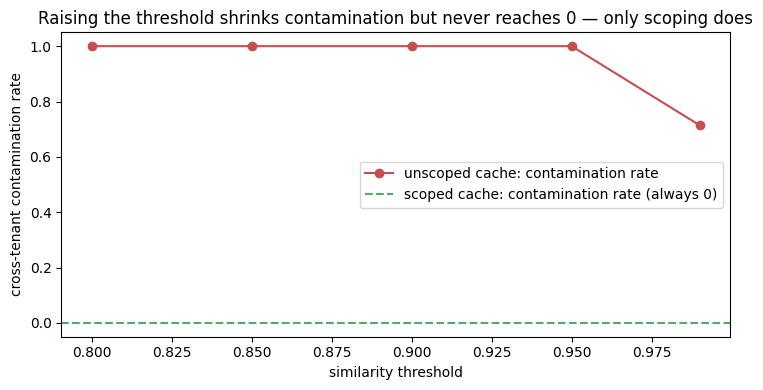

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]
unscoped_contam = []
for t in thresholds:
    c = SemanticCache(embed_fn=embed_texts, threshold=t, max_entries=50)
    for q, a in ACME_QA: c.put(q, a)
    unscoped_contam.append(sum(1 for q in BOLT_QUERIES if c.get(q) is not None) / len(BOLT_QUERIES))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(thresholds, unscoped_contam, marker="o", color="#C44E52", label="unscoped cache: contamination rate")
ax.axhline(contaminated_scoped / len(BOLT_QUERIES), color="#55A868", ls="--", label="scoped cache: contamination rate (always 0)")
ax.set_xlabel("similarity threshold"); ax.set_ylabel("cross-tenant contamination rate")
ax.set_title("Raising the threshold shrinks contamination but never reaches 0 — only scoping does")
ax.set_ylim(-0.05, 1.05); ax.legend(); plt.tight_layout(); plt.show()

*Contamination trends down as the threshold rises, but never structurally closes — a query worded identically to a cached one always clears any threshold below 1.0. Scoping isn't a better point on the same curve; it's a different curve that's flat at zero.*

## Breach 2: a shared vector store

The same failure, one layer down: a RAG-style knowledge base with both tenants' documents in one collection. Bolt's query about "the refund window in our contract" is answered by cosine similarity alone — and Acme's phrasing of the same universal question can outrank Bolt's own document entirely.

In [5]:
store = NamespacedStore(embed_fn=embed_texts)
store.add(acme, [
    "Acme's enterprise contract includes a 30-day refund window.",
    "Acme's primary contact is Priya Shah, account manager.",
    "Acme's data retention period is 90 days per their DPA.",
])
store.add(bolt, [
    "Bolt's enterprise contract includes a 60-day refund window.",
    "Bolt's primary contact is Diego Ruiz, account manager.",
])

query = "What is the refund window in our contract?"

print("--- enforce_isolation=False (the breach) ---")
unsafe_hits = store.query(bolt, query, k=5, enforce_isolation=False)
for h in unsafe_hits:
    print(f"  score={h['score']:.3f}  owner={h['owner_tenant']:6}  {h['text']}")
contaminated = sum(1 for h in unsafe_hits if h["owner_tenant"] not in (bolt.tenant_id, "shared"))
print(f"contamination@{len(unsafe_hits)}: {contaminated}/{len(unsafe_hits)}")

print("\n--- enforce_isolation=True (the fix) ---")
safe_hits = store.query(bolt, query, k=5, enforce_isolation=True)
for h in safe_hits:
    print(f"  score={h['score']:.3f}  owner={h['owner_tenant']:6}  {h['text']}")
contaminated_safe = sum(1 for h in safe_hits if h["owner_tenant"] not in (bolt.tenant_id, "shared"))
print(f"contamination@{len(safe_hits)}: {contaminated_safe}/{len(safe_hits)}")

--- enforce_isolation=False (the breach) ---
  score=0.667  owner=acme    Acme's enterprise contract includes a 30-day refund window.
  score=0.627  owner=bolt    Bolt's enterprise contract includes a 60-day refund window.
  score=0.225  owner=acme    Acme's data retention period is 90 days per their DPA.
  score=0.141  owner=acme    Acme's primary contact is Priya Shah, account manager.
  score=0.082  owner=bolt    Bolt's primary contact is Diego Ruiz, account manager.
contamination@5: 3/5

--- enforce_isolation=True (the fix) ---
  score=0.627  owner=bolt    Bolt's enterprise contract includes a 60-day refund window.
  score=0.082  owner=bolt    Bolt's primary contact is Diego Ruiz, account manager.
contamination@2: 0/2


Acme's answer doesn't just leak into Bolt's results — it out-ranks Bolt's OWN document (Acme's phrasing happens to be a slightly closer semantic match to the generic query). A tenant asking about their own contract can get someone else's contract terms back as the top result, and nothing about the similarity score would look wrong.

Three real-world isolation schemes, in order of strength: **per-tenant collection** (strongest — physically separate indexes, most operational overhead), **shared collection + mandatory metadata filter** (one omitted `where` clause is a leak — this is what `enforce_isolation=True` simulates above), **shared collection + post-filter** (filter results after retrieval — also means fewer than `k` results survive when a tenant has little content, silently starving their own recall).

## Breach 3: cross-user memory contamination

Notebook 22b's agent memory is scoped by *directory*. If two users' sessions point at the SAME directory — an easy mistake if the path isn't derived from who's actually asking — a fact user A shared privately surfaces in user B's recalled context.

In [6]:
class TinyMemory:
    # Minimal file-backed memory in 22b's shape (embed + cosine recall) -- linked, not rebuilt.
    def __init__(self, directory):
        self.path = Path(directory) / "facts.json"
        self.path.parent.mkdir(parents=True, exist_ok=True)
        self.facts = json.loads(self.path.read_text()) if self.path.exists() else []
    def remember(self, text):
        self.facts.append(text)
        self.path.write_text(json.dumps(self.facts))
    def recall(self, query, k=2):
        if not self.facts:
            return []
        vecs = embed_texts(self.facts)
        query_vec = embed_texts([query])[0]
        sims = vecs @ query_vec / (np.linalg.norm(vecs, axis=1) * np.linalg.norm(query_vec) + 1e-9)
        return [self.facts[i] for i in np.argsort(-sims)[:k]]

shared_dir = tempfile.mkdtemp(prefix="shared_memory_")

# User A's session writes a private fact.
memory_a = TinyMemory(shared_dir)
memory_a.remember("The user is allergic to penicillin.")
memory_a.remember("The user prefers appointments in the morning.")

# A FRESH session as user B, pointed at the SAME directory (the bug: no tenant in the path).
memory_b = TinyMemory(shared_dir)
recalled = memory_b.recall("What should the doctor know before prescribing medication?")
assembled_prompt = ("System: use these facts about the CURRENT user.\n"
                     + "\n".join(f"- {r}" for r in recalled) + "\nUser: What can I take for a headache?")
print("user B's assembled prompt, drawing from a SHARED memory directory:\n")
print(assembled_prompt)
print("\n<- user A's allergy leaked into a conversation user A was never part of")

user B's assembled prompt, drawing from a SHARED memory directory:

System: use these facts about the CURRENT user.
- The user is allergic to penicillin.
- The user prefers appointments in the morning.
User: What can I take for a headache?

<- user A's allergy leaked into a conversation user A was never part of


In [7]:
# The fix: derive the memory path from TenantContext.namespace(), never from a bare shared dir.
user_a_ctx = TenantContext(tenant_id="clinic", user_id="patient_A")
user_b_ctx = TenantContext(tenant_id="clinic", user_id="patient_B")

memory_a_scoped = TinyMemory(Path(shared_dir) / user_a_ctx.namespace())
memory_a_scoped.remember("The user is allergic to penicillin.")

memory_b_scoped = TinyMemory(Path(shared_dir) / user_b_ctx.namespace())
recalled_scoped = memory_b_scoped.recall("What should the doctor know before prescribing medication?")
print("user B's recall from a namespace-scoped directory:", recalled_scoped or "(nothing -- correct)")

user B's recall from a namespace-scoped directory: (nothing -- correct)


In [8]:
if HAS_ANTHROPIC:
    contaminated_answer = client.messages.create(model=TEACH_MODEL, max_tokens=100,
        messages=[{"role": "user", "content": assembled_prompt}]).content[0].text
    clean_prompt = "System: use these facts about the CURRENT user.\nUser: What can I take for a headache?"
    clean_answer = client.messages.create(model=TEACH_MODEL, max_tokens=100,
        messages=[{"role": "user", "content": clean_prompt}]).content[0].text
    print("WITH contaminated context:\n", contaminated_answer)
    print("\nWITHOUT contaminated context:\n", clean_answer)
else:
    print("[skipped: no ANTHROPIC_API_KEY] -- expected: the contaminated prompt causes the model to "
          "factor in user A's penicillin allergy when answering a question asked by user B.")

WITH contaminated context:
 # Headache Relief Options

Here are some common over-the-counter options that are safe for you:

## Pain Relievers
- **Acetaminophen** (Tylenol) - 650-1000 mg every 4-6 hours
- **Ibuprofen** (Advil, Motrin) - 200-400 mg every 4-6 hours
- **Naproxen**

WITHOUT contaminated context:
 # Headache Relief Options

Here are some common approaches:

## Over-the-Counter Medications
- **Acetaminophen** (Tylenol)
- **Ibuprofen** (Advil, Motrin)
- **Aspirin**
- **Naproxen** (Aleve)

## Non-Medication Strategies
- Rest in a quiet, dark room
- Apply a cold or warm


## Cost attribution: per-tenant, per-journey

Notebook 32 built per-**feature** budgets (`FEATURE_BUDGETS`, `daily_cost_ceiling`). It never asked "which tenant" or "which user journey" — the same gap the previous two breaches share. `agentkit.tenancy.CostLedger` uses nb32's exact price shape and adds that missing dimension.

In [9]:
PRICE = {"cheap": {"input": 1.00, "output": 5.00}}  # nb32's PRICE shape, unchanged
ledger = CostLedger(PRICE)

tenants = {
    "acme": [TenantContext("acme", "u1", "onboarding"), TenantContext("acme", "u2", "support")],
    "bolt": [TenantContext("bolt", "u1", "onboarding")],
}
features = ["chat_reply", "document_summarization"]
rng = random.Random(0)
for tenant_id, contexts in tenants.items():
    n_calls = 40 if tenant_id == "acme" else 15  # acme is the heavier user
    for _ in range(n_calls):
        ctx = rng.choice(contexts)
        feature = rng.choice(features)
        ledger.record(ctx, feature, "cheap", in_tok=rng.randint(100, 800), out_tok=rng.randint(50, 300))

print("cost by tenant:\n", ledger.report(by="tenant_id"))
print("\ncost by feature:\n", ledger.report(by="feature"))
print(f"\nacme's 'onboarding' journey cost: ${ledger.total(tenant_id='acme', journey_id='onboarding'):.4f}")
print(f"acme's TOTAL cost (all journeys):  ${ledger.total(tenant_id='acme'):.4f}")
print("(nb32 could tell you Acme's chat_reply cost overall -- it could NOT tell you what onboarding, "
      "specifically, cost Acme -- that's the dimension this notebook adds)")

cost by tenant:
   tenant_id      cost
0      acme  0.055357
1      bolt  0.019468

cost by feature:
                   feature      cost
0              chat_reply  0.041303
1  document_summarization  0.033522

acme's 'onboarding' journey cost: $0.0342
acme's TOTAL cost (all journeys):  $0.0554
(nb32 could tell you Acme's chat_reply cost overall -- it could NOT tell you what onboarding, specifically, cost Acme -- that's the dimension this notebook adds)


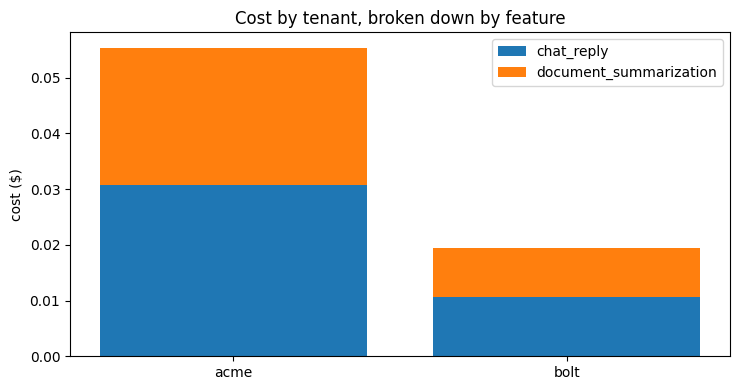

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4))
tenant_ids = list(tenants.keys())
bottom = np.zeros(len(tenant_ids))
for feature in features:
    costs = [ledger.total(tenant_id=t, feature=feature) for t in tenant_ids]
    ax.bar(tenant_ids, costs, bottom=bottom, label=feature)
    bottom += np.array(costs)
ax.set_ylabel("cost ($)"); ax.set_title("Cost by tenant, broken down by feature")
ax.legend(); plt.tight_layout(); plt.show()

*Unit economics read directly off this table: at a flat per-seat price, a tenant whose feature mix skews toward the expensive feature is less profitable than one whose usage looks identical in raw call count.*

## Per-tenant budget enforcement — the 28b interlock

`CostLedger.make_budget_hook` returns a `pre_hook` for `agentkit.contracts.checked_execute` — the exact hook mechanism 28b built for validation now gates tool calls on **spend**, per tenant, with no cross-tenant interference.

In [11]:
TOOL_SCHEMAS = [{"name": "send_email", "description": "Send a notification email.",
                  "input_schema": {"type": "object", "properties": {"to": {"type": "string"}}, "required": ["to"]}}]
contracts = contracts_from_schemas(TOOL_SCHEMAS)
implementations = {"send_email": lambda to: f"sent to {to}"}

acme_ctx = tenants["acme"][0]
acme_spend = ledger.total(tenant_id="acme")
print(f"acme has already spent ${acme_spend:.4f} today")

over_budget_hook = ledger.make_budget_hook(acme_ctx, daily_ceiling_usd=acme_spend * 0.5)  # already exceeded
result = checked_execute("send_email", {"to": "ops@acme.example"}, contracts, implementations, pre_hooks=[over_budget_hook])
print("acme call (over its own budget):", result.status, "-", result.output)

bolt_ctx = tenants["bolt"][0]
bolt_hook = ledger.make_budget_hook(bolt_ctx, daily_ceiling_usd=1.0)  # bolt's own, unrelated ceiling
result = checked_execute("send_email", {"to": "ops@bolt.example"}, contracts, implementations, pre_hooks=[bolt_hook])
print("bolt call (its own budget, unaffected by acme):", result.status, "-", result.output)

acme has already spent $0.0554 today
acme call (over its own budget): rejected - error: tenant 'acme' has exceeded its daily budget ($0.0554 >= $0.0277) — call rejected
bolt call (its own budget, unaffected by acme): ok - sent to ops@bolt.example


One tenant hitting its ceiling rejects only that tenant's next call — a noisy-neighbor tenant can never silently spend another tenant's budget, because the hook is built from that specific tenant's `TenantContext`, not from any global counter.

## Exercises

In [12]:
# Exercise 1 (Warm-up): threshold is not a safety knob
# Task: Using the breach-1 workload above, sweep SemanticCache.threshold from 0.80 to 0.99 on the
#       UNSCOPED cache and separately measure hit-rate on Acme's own paraphrases at each threshold.
#       Plot contamination rate and Acme's own hit-rate on the same axes. Write one sentence on
#       which of the two the threshold actually controls, and which it only weakly affects.
# Hint: you already have unscoped_contam computed above for several thresholds -- add a matching
#       sweep for acme_paraphrases hit-rate and plot both curves together.

# YOUR CODE HERE

In [13]:
# Exercise 2 (Apply): break isolation deliberately, then catch it with a test
# Task: Implement a SUBTLY wrong namespace function: TenantContext.namespace() normally returns
#       "tenant_id/user_id" -- write a broken version that returns JUST user_id (dropping
#       tenant_id). This collides whenever two DIFFERENT tenants happen to share a user_id, e.g.
#       both tenants have an admin account literally named "admin". Then write
#       contamination_test(namespace_fn) -> bool that provably catches this bug (using two
#       tenants that both have a user "admin", store a fact for one, and check whether the other
#       can recall it) -- and confirm the CORRECT namespace_fn passes while the broken one fails.
# Hint: the deliverable is the TEST, not just noticing the bug by eye -- isolation is a property
#       you regression-gate (notebook 33), not one you eyeball once and trust forever.

# YOUR CODE HERE

In [14]:
# Exercise 3 (Extend): route a tenant on cost AND quality
# Task: Extend the cost-attribution workload with a per-record quality score (use judge_score if
#       HAS_ANTHROPIC, else a deterministic stub like len(feature) % 2 for offline runs). Build a
#       per-tenant table of cost-per-journey alongside mean quality, and decide which tenant (if
#       either) should be migrated to a cheaper model tier -- state the specific SLO your decision
#       protects (e.g. "acme's onboarding journey must stay above 0.8 quality; below that, cost
#       savings aren't worth the support tickets it would generate").
# Hint: this is the same shape as notebook 32's routed_ask decision, but keyed by TENANT+JOURNEY
#       instead of by a single global cost/quality tradeoff.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
acme_hit_by_threshold = []
for t in thresholds:
    c = SemanticCache(embed_fn=embed_texts, threshold=t, max_entries=50)
    for q, a in ACME_QA: c.put(q, a)
    acme_hit_by_threshold.append(sum(1 for q in acme_paraphrases if c.get(q) is not None) / len(acme_paraphrases))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, unscoped_contam, marker="o", color="#C44E52", label="contamination rate")
ax.plot(thresholds, acme_hit_by_threshold, marker="o", color="#4C72B0", label="acme's own hit-rate")
ax.legend(); plt.tight_layout(); plt.show()
# Threshold mostly trades acme's OWN hit-rate away as it rises; contamination falls too, but much
# more slowly and never to zero. Threshold is fundamentally a PERFORMANCE knob (recall vs.
# precision within one tenant's traffic) that happens to weakly correlate with safety -- not a
# safety knob in its own right.

# Exercise 2
def broken_namespace(ctx):
    return ctx.user_id  # BUG: drops tenant_id

def contamination_test(namespace_fn):
    tenant_x = TenantContext(tenant_id="acme", user_id="admin")
    tenant_y = TenantContext(tenant_id="bolt", user_id="admin")  # same user_id, DIFFERENT tenant
    store_ns = {}
    store_ns[namespace_fn(tenant_x)] = "acme's admin-only secret"
    leaked = namespace_fn(tenant_y) in store_ns and store_ns[namespace_fn(tenant_y)] == "acme's admin-only secret"
    return not leaked  # True = isolation held, False = isolation broken

print("broken namespace_fn passes isolation test:", contamination_test(broken_namespace))       # False
print("correct TenantContext.namespace passes:   ", contamination_test(lambda ctx: ctx.namespace()))  # True

# Exercise 3
def quality_stub(journey_id):
    return 0.75 if journey_id == "support" else 0.9  # offline deterministic stand-in; use judge_score if HAS_ANTHROPIC
rows = []
for tenant_id, contexts in tenants.items():
    for journey_id in {c.journey_id for c in contexts if c.journey_id}:
        cost = ledger.total(tenant_id=tenant_id, journey_id=journey_id)
        rows.append({"tenant": tenant_id, "journey": journey_id, "cost": cost, "quality": quality_stub(journey_id)})
import pandas as pd
print(pd.DataFrame(rows))
# Decision: migrate a tenant/journey pair to the cheap tier only if its quality stays above the
# journey's own SLO threshold after the switch -- e.g. "acme/onboarding must stay >= 0.8; if a
# cheaper model drops it below that, the savings aren't worth the support-ticket cost it creates."
```
</details>

## Key Takeaways
- Every piece of shared state — semantic cache, vector store, agent memory — leaks between tenants **unless a tenant identity is explicitly threaded through every read and write.** "No ambient tenant" is the rule; `TenantContext.namespace()` is the mechanism.
- **Threshold/similarity tuning cannot structurally fix cross-tenant contamination** — measured directly: even a 0.99 similarity threshold left most identically-worded cross-tenant queries contaminated. Only scoping (a different namespace per tenant) drives contamination to zero.
- The SAME contamination mechanism appears at every layer — cache, vector store, memory — and the fix is identical every time: derive the namespace/path from the requesting principal, never from a shared default.
- **Cost attribution needs a journey dimension**, not just tenant and feature — `CostLedger.total(tenant_id=..., journey_id=...)` answers "what did onboarding cost Acme specifically," which notebook 32's per-feature budgets structurally couldn't.
- **Isolation is a property you regression-test, not one you eyeball once.** A namespace function that's subtly wrong (drops a field, collides on shared IDs like "admin") passes every manual check until the exact wrong pair of tenants collides — Exercise 2's `contamination_test` is the shape that belongs in notebook 33's gate.

## What's Next
Notebook 31 (MCP) returns to tool-serving infrastructure with this notebook's isolation lessons in hand; notebook 33 (CI for AI) is where `contamination_test`-shaped checks actually get wired into a merge gate so an isolation regression fails the build instead of shipping.